# DistilBERT: Contextual Transformer Model

This notebook fine-tunes a pretrained DistilBERT model for the mental-health text classification experiment.

The same fixed train, validation, and test splits from `02_dataset_preparation.ipynb` are used so that the Transformer model can be compared fairly with the TF-IDF and BiLSTM experiments.

## Research purpose

DistilBERT provides contextual representations learned through large-scale pretraining. This experiment tests whether pretrained contextual representations improve mental-health text classification compared with sparse TF-IDF features and a BiLSTM.

## 1. Import libraries

In [1]:
from pathlib import Path
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

## 2. Set random seeds and device

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3. Load the fixed dataset splits

In [3]:
possible_dirs = [
    Path("data/prepared"),
    Path("../data/prepared")
]

DATA_DIR = None

for directory in possible_dirs:
    if (directory / "train.csv").exists():
        DATA_DIR = directory
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the prepared dataset. "
        "Please run 02_dataset_preparation.ipynb first."
    )

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

Training set: (38115, 2)
Validation set: (8167, 2)
Test set: (8168, 2)


## 4. Create label mappings

In [4]:
labels = sorted(train_df["label"].unique())
label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Label mapping:")
for label, label_id in label_to_id.items():
    print(label_id, "->", label)

Label mapping:
0 -> Anxiety
1 -> Depression
2 -> Happy
3 -> Mentalhealth
4 -> Normal
5 -> Sad
6 -> Stress
7 -> Suicidal


## 5. Load the pretrained DistilBERT tokenizer

The tokenizer is provided by the pretrained DistilBERT model. A maximum sequence length of 128 tokens is used to keep the experiment consistent with the earlier models.

In [5]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Maximum sequence length:", MAX_LEN)

Model: distilbert-base-uncased
Maximum sequence length: 128


## 6. Create PyTorch dataset

Tokenization is performed separately for each split. The pretrained tokenizer does not learn a new vocabulary from the validation or test data.

In [6]:
class MentalHealthDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts = dataframe["text"].tolist()
        self.labels = [label_to_id[label] for label in dataframe["label"]]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            str(self.texts[index]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[index], dtype=torch.long)
        }

        return item


train_dataset = MentalHealthDataset(train_df, tokenizer, MAX_LEN)
val_dataset = MentalHealthDataset(val_df, tokenizer, MAX_LEN)
test_dataset = MentalHealthDataset(test_df, tokenizer, MAX_LEN)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2383
Validation batches: 511
Test batches: 511


## 7. Create the DistilBERT model

The pretrained DistilBERT encoder is combined with a classification head for the eight mental-health categories.

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id_to_label,
    label2id=label_to_id
).to(device)

print("Model loaded successfully.")
print("Number of labels:", len(labels))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.
Number of labels: 8


## 8. Handle class imbalance

The training set is imbalanced, so inverse-frequency class weights are used in the cross-entropy loss.

In [8]:
class_counts = train_df["label"].value_counts().reindex(labels)
class_weights = len(train_df) / (len(labels) * class_counts.values)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for label, weight in zip(labels, class_weights.cpu().numpy()):
    print(f"{label}: {weight:.4f}")

Class weights:
Anxiety: 1.4879
Depression: 0.4300
Happy: 9.9465
Mentalhealth: 3.5006
Normal: 0.4246
Sad: 4.1538
Stress: 2.9703
Suicidal: 0.5941


## 9. Training setup

The learning rate and number of epochs follow the controlled Transformer setup used for the project. The validation Macro F1 is used for model selection.

In [9]:
LEARNING_RATE = 2e-5
EPOCHS = 3
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Weight decay:", WEIGHT_DECAY)
print("Warmup steps:", warmup_steps)

Learning rate: 2e-05
Epochs: 3
Weight decay: 0.01
Warmup steps: 714


## 10. Evaluation function

In [10]:
def evaluate_model(model, data_loader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return np.array(all_labels), np.array(all_predictions)

## 11. Fine-tune DistilBERT

The model with the best validation Macro F1 is restored before the final test evaluation.

In [11]:
best_val_f1 = -1.0
best_model_state = None
history = []

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    y_val_ids, y_val_pred_ids = evaluate_model(model, val_loader)

    val_macro_f1 = f1_score(
        y_val_ids,
        y_val_pred_ids,
        average="macro",
        zero_division=0
    )

    average_loss = running_loss / len(train_loader)
    history.append({
        "epoch": epoch + 1,
        "train_loss": average_loss,
        "val_macro_f1": val_macro_f1
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Validation Macro F1: {val_macro_f1:.4f}"
    )

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

training_time = time.time() - start_time

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Training completed in {training_time:.2f} seconds.")
print(f"Best validation Macro F1: {best_val_f1:.4f}")

Epoch 1/3 | Loss: 0.9278 | Validation Macro F1: 0.6936
Epoch 2/3 | Loss: 0.5213 | Validation Macro F1: 0.7482
Epoch 3/3 | Loss: 0.3800 | Validation Macro F1: 0.7584
Training completed in 1541.38 seconds.
Best validation Macro F1: 0.7584


## 12. Plot training progress

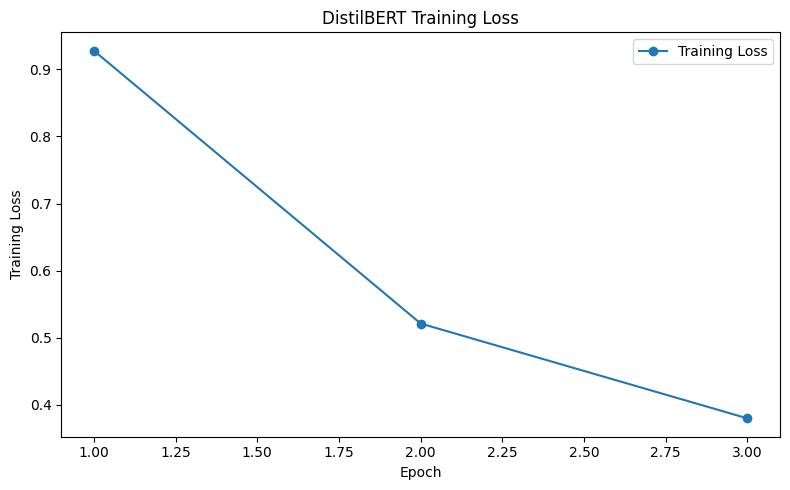

In [12]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("DistilBERT Training Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Final test evaluation

In [13]:
y_test_ids, y_test_pred_ids = evaluate_model(model, test_loader)

y_test_labels = [id_to_label[i] for i in y_test_ids]
y_test_pred_labels = [id_to_label[i] for i in y_test_pred_ids]

test_accuracy = accuracy_score(y_test_labels, y_test_pred_labels)
test_macro_precision = precision_score(
    y_test_labels, y_test_pred_labels, average="macro", zero_division=0
)
test_macro_recall = recall_score(
    y_test_labels, y_test_pred_labels, average="macro", zero_division=0
)
test_macro_f1 = f1_score(
    y_test_labels, y_test_pred_labels, average="macro", zero_division=0
)
test_weighted_f1 = f1_score(
    y_test_labels, y_test_pred_labels, average="weighted", zero_division=0
)

print("DistilBERT Test Results")
print("-----------------------")
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Macro Precision:   {test_macro_precision:.4f}")
print(f"Macro Recall:      {test_macro_recall:.4f}")
print(f"Macro F1:          {test_macro_f1:.4f}")
print(f"Weighted F1:       {test_weighted_f1:.4f}")

DistilBERT Test Results
-----------------------
Accuracy:          0.7883
Macro Precision:   0.7340
Macro Recall:      0.7682
Macro F1:          0.7449
Weighted F1:       0.7908


## 14. Per-class performance

In [14]:
report = classification_report(
    y_test_labels,
    y_test_pred_labels,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Anxiety       0.87      0.85      0.86       687
  Depression       0.80      0.66      0.72      2375
       Happy       0.86      0.74      0.79       102
Mentalhealth       0.61      0.73      0.66       292
      Normal       0.96      0.93      0.95      2405
         Sad       0.50      0.63      0.56       246
      Stress       0.60      0.84      0.70       343
    Suicidal       0.66      0.77      0.71      1718

    accuracy                           0.79      8168
   macro avg       0.73      0.77      0.74      8168
weighted avg       0.80      0.79      0.79      8168



## 15. Confusion matrix

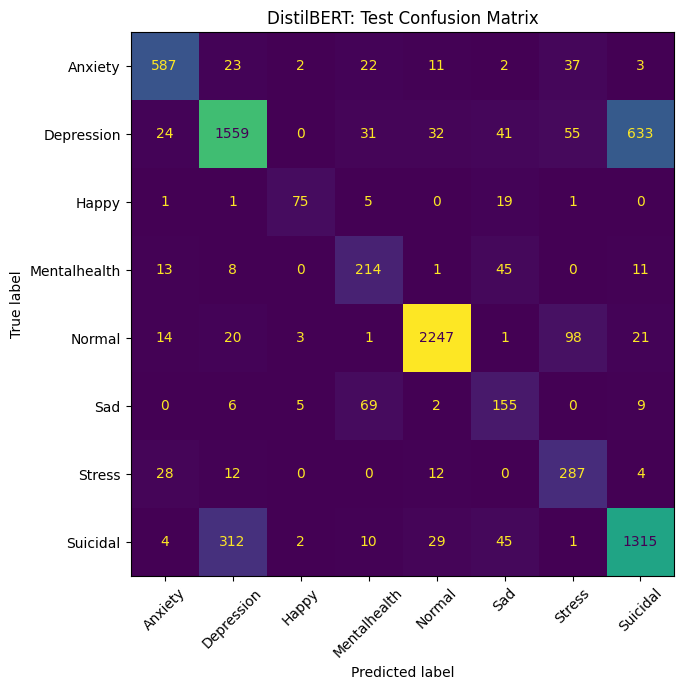

In [15]:
cm = confusion_matrix(
    y_test_labels,
    y_test_pred_labels,
    labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
plt.title("DistilBERT: Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 16. Save DistilBERT results

The results are saved in the same folder as the TF-IDF and BiLSTM results.

In [16]:
results_dir = DATA_DIR.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

distilbert_results = pd.DataFrame([{
    "model": "DistilBERT",
    "accuracy": test_accuracy,
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1,
    "best_validation_macro_f1": best_val_f1,
    "training_time_seconds": training_time,
    "n_train": len(train_df),
    "n_validation": len(val_df),
    "n_test": len(test_df),
    "model_name": MODEL_NAME,
    "max_sequence_length": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "weight_decay": WEIGHT_DECAY
}])

distilbert_results.to_csv(results_dir / "distilbert_results.csv", index=False)
history_df.to_csv(results_dir / "distilbert_training_history.csv", index=False)

print("Saved results to:")
print(results_dir / "distilbert_results.csv")
print(results_dir / "distilbert_training_history.csv")

Saved results to:
..\data\results\distilbert_results.csv
..\data\results\distilbert_training_history.csv


## 17. Final summary

In [17]:
print("DistilBERT experiment completed.")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")

DistilBERT experiment completed.
Test Macro F1: 0.7449
Test Accuracy: 0.7883
Best Validation Macro F1: 0.7584
Training time: 1541.38 seconds
Model: distilbert-base-uncased
Device: cuda
